<a href="https://colab.research.google.com/github/mbowen36-lab/ECGR-4105/blob/main/Homework%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECGR-4105: Homework 4
Name: Matthew Bowen\
Student ID: 801345379

In [643]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn import metrics
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [644]:
df_cancer = pd.read_csv('/content/drive/My Drive/ECGR 4105/Datasets/Cancer.csv')
print(df_cancer.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [645]:
df_housing = pd.read_csv('/content/drive/My Drive/ECGR 4105/Datasets/Housing.csv')
print(df_housing.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [646]:
X = df_cancer.iloc[:, [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]]
Y = df_cancer.iloc[:, 1].replace({'M': '1', 'B': '0'}).astype(float).values

In [647]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

In [648]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [649]:
def give_results():

  accuracy = metrics.accuracy_score(Y_test, Y_pred)
  precision = metrics.precision_score(Y_test, Y_pred)
  recall = metrics.recall_score(Y_test, Y_pred)
  f1 = metrics.f1_score(Y_test, Y_pred)

  print("Accuracy:",accuracy)
  print("Precision:",precision)
  print("Recall:",recall)
  print("F1:",f1)

  cnf_matrix = confusion_matrix(Y_test, Y_pred)

  class_names=[0,1]
  fig, ax = plt.subplots()
  tick_marks = np.arange(len(class_names))
  plt.xticks(tick_marks, class_names)
  plt.yticks(tick_marks, class_names)
  sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
  ax.xaxis.set_label_position("top")
  plt.tight_layout()
  plt.title('Confusion matrix', y=1.1)
  plt.ylabel('Actual label')
  plt.xlabel('Predicted label')

  return accuracy, precision, recall, f1

In [650]:
results = {}

Accuracy: 0.9649122807017544
Precision: 0.9777777777777777
Recall: 0.9361702127659575
F1: 0.9565217391304348


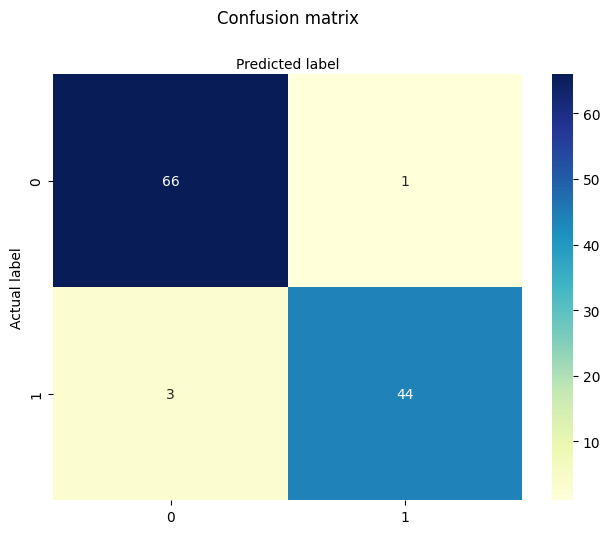

In [651]:
classifier = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01, learning_rate='constant', eta0=0.01, random_state=0)

train_loss, test_loss, train_acc, test_acc = [], [], [], []

for epoch in range(200):
    classifier.partial_fit(X_train, Y_train, classes=np.unique(Y_train))
    train_loss.append(metrics.log_loss(Y_train, classifier.predict_proba(X_train)))
    test_loss.append(metrics.log_loss(Y_test, classifier.predict_proba(X_test)))
    train_acc.append(metrics.accuracy_score(Y_train, classifier.predict(X_train)))
    test_acc.append(metrics.accuracy_score(Y_test, classifier.predict(X_test)))

Y_pred = classifier.predict(X_test)
results['Homework 3'] = give_results()

Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9574468085106383
F1: 0.9782608695652174


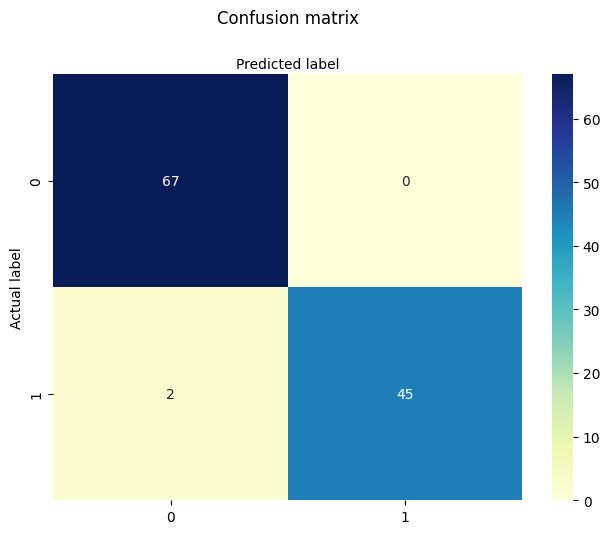

In [652]:
svc = SVC(kernel='rbf')
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
results['RBF'] = give_results()

Accuracy: 0.9824561403508771
Precision: 0.9787234042553191
Recall: 0.9787234042553191
F1: 0.9787234042553191


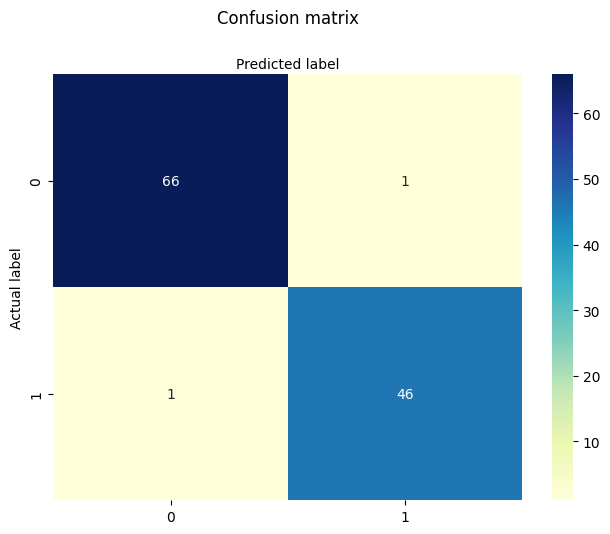

In [653]:
svc = SVC(kernel='linear')
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
results['Linear'] = give_results()

Accuracy: 0.7631578947368421
Precision: 0.8846153846153846
Recall: 0.48936170212765956
F1: 0.6301369863013698


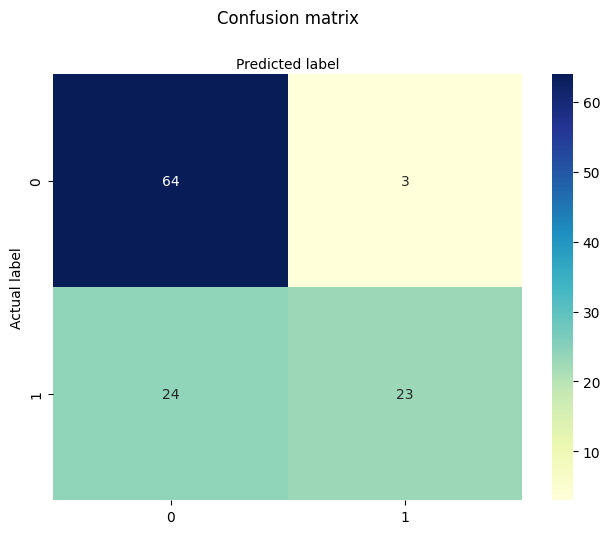

In [654]:
svc = SVC(kernel='poly',degree=2)
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
results['Poly (2nd)'] = give_results()

Accuracy: 0.9035087719298246
Precision: 1.0
Recall: 0.7659574468085106
F1: 0.8674698795180723


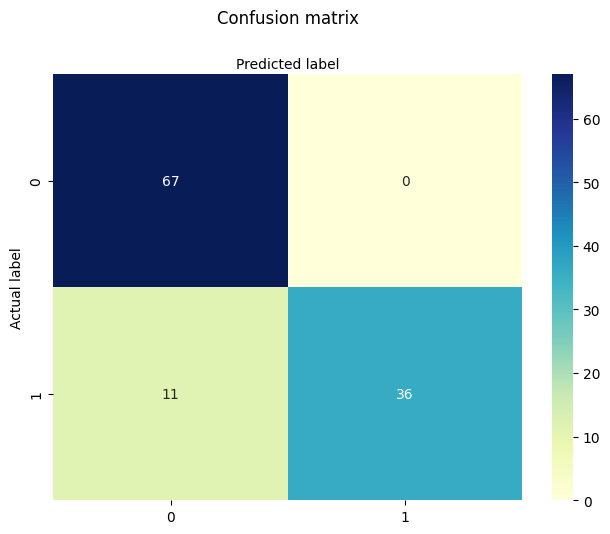

In [655]:
svc = SVC(kernel='poly',degree=3)
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
results['Poly (3rd)'] = give_results()

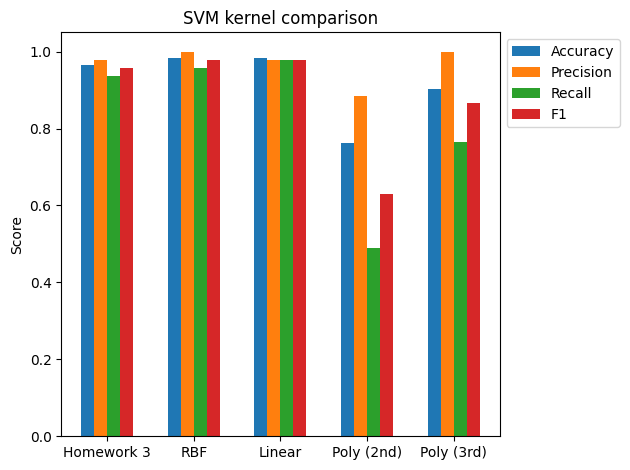

In [656]:
kernels = list(results.keys())
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']

x = np.arange(len(kernels))
bar_width = 0.15

for i, name in enumerate(metric_names):
    heights = [results[k][i] for k in kernels]
    plt.bar(x + i * bar_width, heights, width=bar_width, label=name)

plt.xticks(x + bar_width * 1.5, kernels)
plt.ylabel('Score')
plt.title('SVM kernel comparison')
plt.ylim(0, 1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [657]:
X = df_housing.iloc[:, [1,2,3,4,5,6,7,8,9,10,11]].replace({'yes': '1', 'no': '0'}).astype(float).values
Y = df_housing.iloc[:, 0]

In [658]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

In [659]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [660]:
sc_Y = StandardScaler()
Y_train_scaled = sc_Y.fit_transform(Y_train.values.reshape(-1, 1)).ravel()

In [661]:
def give_results():

  r2 = metrics.r2_score(Y_test, Y_pred)
  rmse = np.sqrt(metrics.mean_squared_error(Y_test, Y_pred))

  print("R^2:",r2)
  print("RMSE:",rmse)

  plt.figure(figsize=(6, 5))
  plt.scatter(Y_test, Y_pred, color='darkorange', alpha=0.7, label='Test houses')
  plt.plot([0, 1.3e7], [0, 1.3e7], color='red', lw=2, label='Perfect prediction')
  plt.xlim(0, 1.3e7)
  plt.ylim(0, 1.3e7)
  plt.title(f"Data VS Target (R² = {r2:.3f})")
  plt.xlabel('Actual price')
  plt.ylabel('Predicted price')
  plt.legend()
  plt.show()

  return r2, rmse

In [662]:
results = {}

R^2: 0.6732953200315301
RMSE: 970260.5173731716


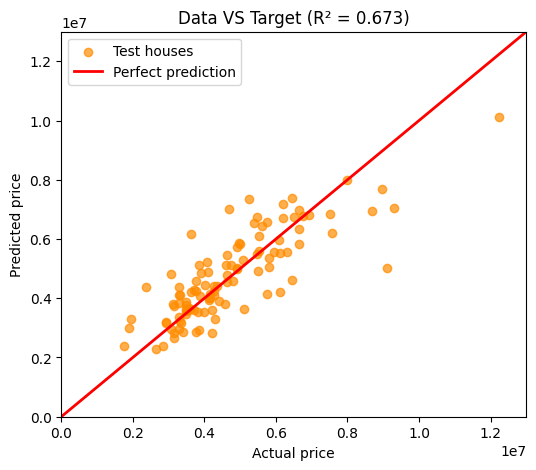

In [663]:
ridge = Ridge(alpha=50)
ridge.fit(X_train, Y_train)
Y_pred = ridge.predict(X_test)
results['Ridge (HW2)'] = give_results()

R^2: 0.5798185613266387
RMSE: 1100345.6049168592


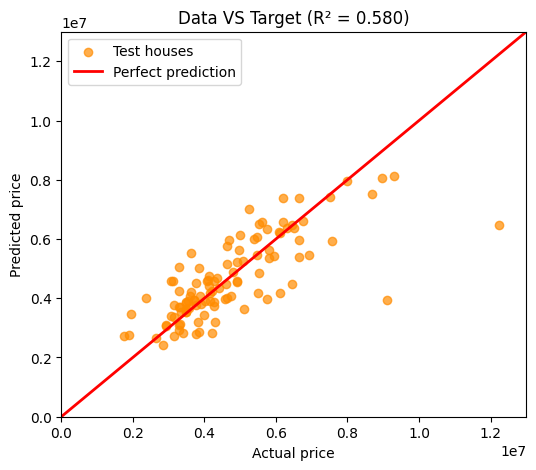

In [664]:
svr = SVR(kernel='rbf')
svr.fit(X_train, Y_train_scaled)
Y_pred = sc_Y.inverse_transform(svr.predict(X_test).reshape(-1, 1)).ravel()
results['RBF'] = give_results()

R^2: 0.6719886677863279
RMSE: 972198.8550496018


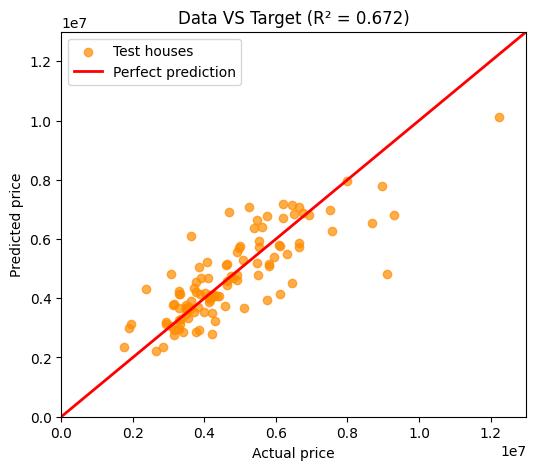

In [665]:
svr = SVR(kernel='linear')
svr.fit(X_train, Y_train_scaled)
Y_pred = sc_Y.inverse_transform(svr.predict(X_test).reshape(-1, 1)).ravel()
results['Linear'] = give_results()

R^2: 0.42697075542353
RMSE: 1284988.0078131782


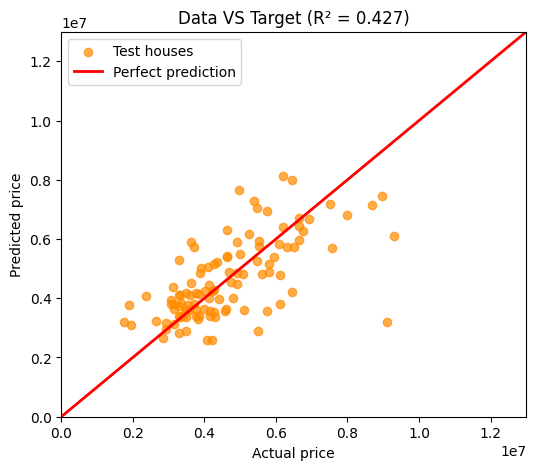

In [666]:
svr = SVR(kernel='poly',degree=2)
svr.fit(X_train, Y_train_scaled)
Y_pred = sc_Y.inverse_transform(svr.predict(X_test).reshape(-1, 1)).ravel()
results['Poly (2nd)'] = give_results()

R^2: 0.29216886790613505
RMSE: 1428155.547713075


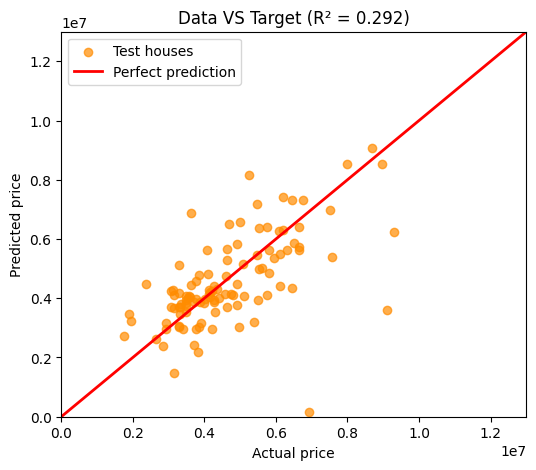

In [667]:
svr = SVR(kernel='poly',degree=3)
svr.fit(X_train, Y_train_scaled)
Y_pred = sc_Y.inverse_transform(svr.predict(X_test).reshape(-1, 1)).ravel()
results['Poly (3rd)'] = give_results()

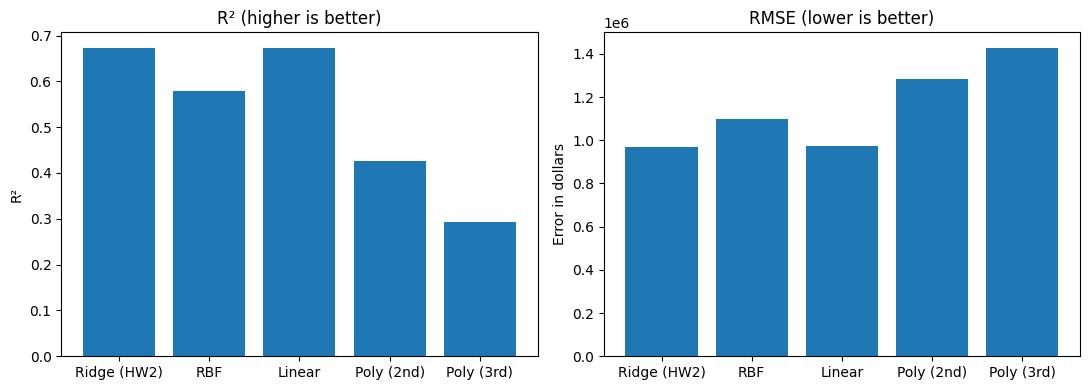

In [668]:
models = list(results.keys())
r2_values = [results[m][0] for m in models]
rmse_values = [results[m][1] for m in models]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(models, r2_values)
ax1.set_title('R² (higher is better)')
ax1.set_ylabel('R²')

ax2.bar(models, rmse_values)
ax2.set_title('RMSE (lower is better)')
ax2.set_ylabel('Error in dollars')

plt.tight_layout()
plt.show()